# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Часть 1. EDA

1. Скачайте данные с Kaggle по ценам на жильё в Airbnb в Нью-Йорке:
https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data
2. Пройдите по основным шагам работы с данными: 
    - выкиньте ненужные признаки: id, name, host_id, host_name, last_review
    - визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots
    - по результатам анализа произведите предобработку переменных


## Шаг 0. Обзор данных

In [19]:
row_filepath = Path("data/raw/AB_NYC_2019.csv")

df_row = pd.read_csv(row_filepath, sep=",", encoding="utf-8")
df_row.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
15782,12763385,Bedroom in Classic Clinton Hill,9784153,Santiago,Brooklyn,Clinton Hill,40.68752,-73.96180,Private room,99,3,0,NaN,NaN,1,0
38782,30393759,Smart Studio in Heart of West Village w/ Doorm...,107434423,Blueground,Manhattan,West Village,40.73035,-74.00324,Entire home/apt,334,30,0,NaN,NaN,232,280
3954,2461540,Big BR 15 min away from Manhattan,12587147,Joao,Queens,Astoria,40.75799,-73.92006,Private room,75,7,186,2019-06-10,2.93,1,193
40537,31428772,Private Studio 25 Minutes from Midtown,42761,Jessica,Bronx,Claremont Village,40.84487,-73.90811,Private room,80,2,1,2019-01-20,0.18,1,156
30509,23611312,Spacious & Cozy Historical Flat,19922549,Dan,Manhattan,Two Bridges,40.71150,-73.99520,Entire home/apt,300,3,24,2019-06-30,1.76,1,32
7344,5414911,“纽约之家 ”独立洗手间PrivateBathroom,27673980,Amy,Queens,Flushing,40.74428,-73.83330,Private room,65,1,76,2019-04-08,1.46,8,25
1187,505029,SPACIOUS Fabulous Sunny Loft for 2 wks in Fall,2490471,Ann,Manhattan,East Village,40.72454,-73.97944,Entire home/apt,175,4,13,2018-11-16,0.17,1,0
28705,22203734,Charming 1 bedroom APT in the heart of Astoria,90285941,Abhi,Queens,Astoria,40.76337,-73.92801,Entire home/apt,70,4,1,2018-01-05,0.05,1,0
30989,24024322,"Luxury KING 2br, Airports & Times SQ minutes away",111978355,Katarina,Queens,Elmhurst,40.73421,-73.87387,Entire home/apt,230,2,30,2019-06-14,2.97,2,51
38988,30466737,Art Life in the City – from Brooklyn to Manhattan,1936796,JenJoy,Brooklyn,Williamsburg,40.71228,-73.93782,Private room,72,2,3,2019-06-30,3.00,2,0


In [20]:
df_row.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [21]:
df_row[df_row["last_review"].isna()]["number_of_reviews"].unique()

array([0])

In [22]:
df_row.duplicated().sum()

np.int64(0)

In [23]:
df_row.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Промежуточный вывод:

id
* неважный признак

host_id
* неважный признак

host_name 
* 21 пропуск
* неважный признак

price - целевая епременная
* min price = 0 ?? 
* mean = 152.720687, а медиана = 106.000000. Среднее больше почти на 50%. Т.к. среднее чувствительно к выбросам в отличие от медианы, это говорит, что справа будут большие значения, утяжеляющие распределение
* std = 240.154170. разброс данных вокруг mean очень выражен. Цены на проживание распределены очень неравномерно, есть большой разброс между дорогими и дешевыми апартаментами
* основной объем апартаметов на рынке сосредоточен в ценовой категории до 175$ (третий квартиль)

minimum_nights
* max = 1250 ??

name
* 16 пропусков
* неважный признак

reviews_per_month
* 10052 пропуск
* прямая связь с last_review и number_of_reviews

last_review
* 10052 порпуск
* прямая связь с reviews_per_month и number_of_reviews
* тип str вместо ожидаемого date
* неважный признак

number_of_reviews
* прямая связь с reviews_per_month и number_of_reviews

## Шаг 1. Выкиньте ненужные признаки: id, name, host_id, host_name, last_review

In [24]:
cols_to_drop = ["id", "name", "host_id", "host_name", "last_review"]
df_preinterim = df_row.drop(columns=cols_to_drop)

df_preinterim

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [25]:
df_preinterim_path = "data/raw/AB_NYC_2019_preinterim.csv"

df_preinterim.to_csv(df_preinterim_path, sep=',', index=False)

In [26]:
df_preinterim.shape

(48895, 11)

## Шаг 2. Визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots

### Подготовительные манипуляции

In [27]:
df_preinterim["room_type"].unique().tolist()

['Private room', 'Entire home/apt', 'Shared room']

In [28]:
df_preinterim["neighbourhood"].nunique()

221

In [29]:
df_numeric = df_preinterim.select_dtypes(include="number")
df_numeric.columns.tolist()

['latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [30]:
df_stings = df_preinterim.select_dtypes(include=["str", "object"])
df_stings.columns.tolist()

['neighbourhood_group', 'neighbourhood', 'room_type']

### Распределение признаков

#### распределение числовых признаков

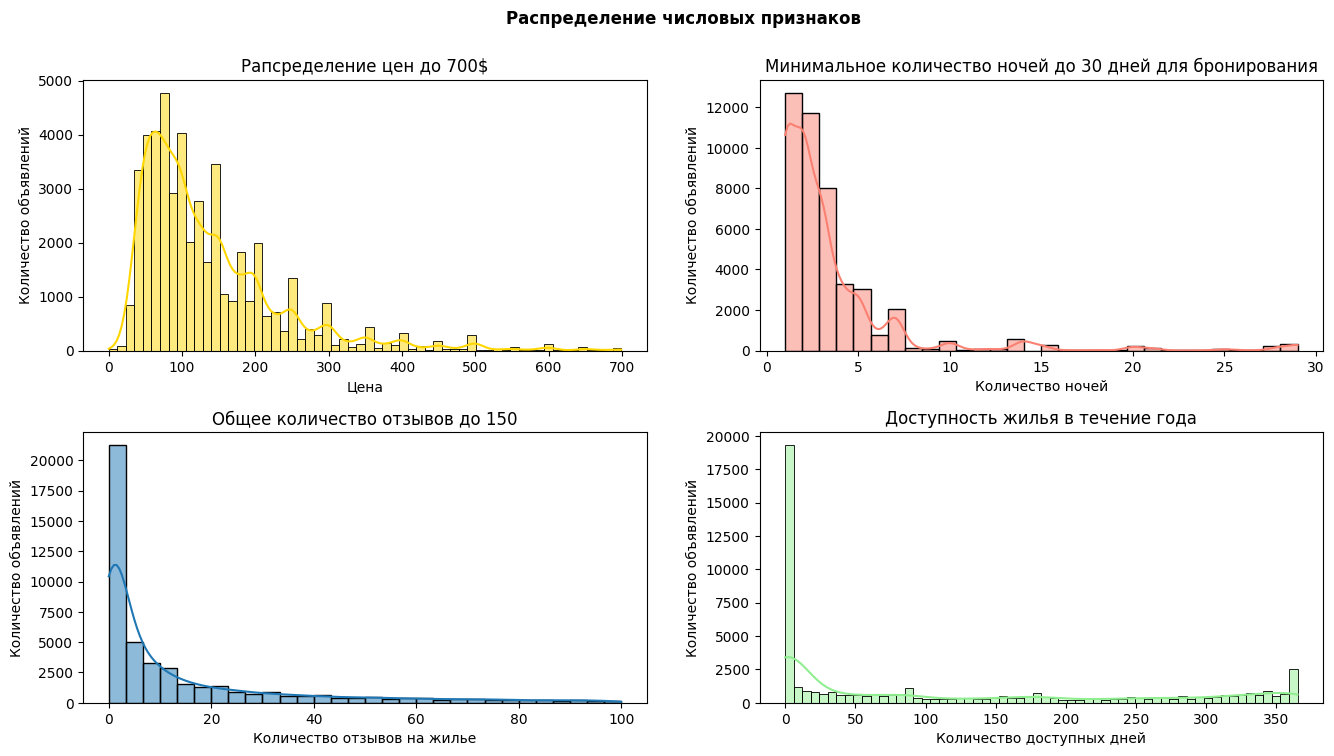

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 7))

# price
sns.histplot(data=df_preinterim[df_preinterim["price"] < 700],  x="price", ax=axes[0, 0],bins = 60, kde=True, color="gold")
axes[0, 0].set_title("Рапсределение цен до 700$")
axes[0, 0].set_xlabel("Цена")
axes[0, 0].set_ylabel("Количество объявлений")

# minimum_nights
sns.histplot(data=df_preinterim[df_preinterim["minimum_nights"] < 30], x="minimum_nights", ax=axes[0, 1], bins = 30, kde=True, color="salmon")
axes[0 , 1].set_title("Минимальное количество ночей до 30 дней для бронирования")
axes[0 , 1].set_xlabel("Количество ночей")
axes[0 , 1].set_ylabel("Количество объявлений")

# number_of_reviews
sns.histplot(data=df_preinterim[df_preinterim["number_of_reviews"] <= 100], x="number_of_reviews", ax=axes[1, 0], bins=30, kde=True)
axes[1, 0].set_title("Общее количество отзывов до 150")
axes[1, 0].set_xlabel("Количество отзывов на жилье")
axes[1, 0].set_ylabel("Количество объявлений")

# availability_365
sns.histplot(data=df_preinterim, x="availability_365", bins=60, ax=axes[1, 1], kde=True,  color="lightgreen")
axes[1, 1].set_title("Доступность жилья в течение года")
axes[1, 1].set_xlabel("Количество доступных дней")
axes[1, 1].set_ylabel("Количество объявлений")

fig.suptitle("Распределение числовых признаков", fontweight="bold", y=1.1)
plt.subplots_adjust(hspace=0.3, top=1)
plt.show()

#### распределение категориальных признаков

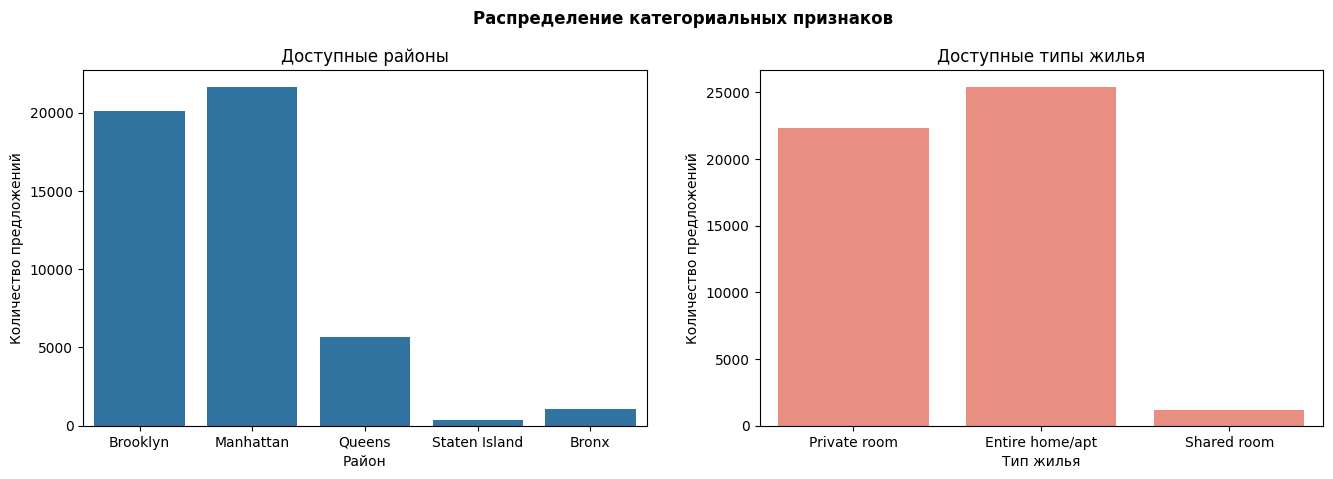

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16,4))

# neighbourhood_group
sns.countplot(data=df_preinterim, x="neighbourhood_group", ax=axes[0])
axes[0].set_title("Доступные районы")
axes[0].set_xlabel("Район")
axes[0].set_ylabel("Количество предложений")

# room_type
sns.countplot(data=df_preinterim, x="room_type", ax=axes[1], color="salmon")
axes[1].set_title("Доступные типы жилья")
axes[1].set_xlabel("Тип жилья")
axes[1].set_ylabel("Количество предложений")

fig.suptitle("Распределение категориальных признаков", fontweight="bold", y=1.15)
plt.subplots_adjust(top=1)

#### Промежуточный вывод:

price
* Гистограмма унимодальна с ярко выраженным пиком и положительной скошенностью - подтвердило гипотезу из "Шаг 0. Обзор данных" о тяжелом хвосте
* Основной ценовой диапазон на жилте - от $50$ до $150$$

minimum_nights
* Гистограмма унимодальна с пологим пиком и положительной скошенностью
* Преобладает краткосрочная аренда, наибольшее количество предложений - аренда на $1$ ночь, также популярны предложения аренды жилья на $2$-$3$ ночи

number_of_reviews
* Гистограмма унимодальна с ярко выраженным пиком и положительной скошенностью
* Подавляющее большинство жилья не имеет отзывов

availability_365. не уверена, что интерпретировала правильно: 
* Гистограмма бимодальна, явно преобладает пик на отметке $0$, это может означать, что жилье до конца года забронировано и свободных мест нет. 
* Также есть небольшой пик на отметке $365$, это может означать, что жилье доступно к аренде круглогодично

neighbourhood_group
* Диаграма имеет 2 ярковыраженных пика
* Наибольшее количество жилья для арнеды расположено в Бруклине и на Манхеттене

room_type
* Диаграма имеет 2 ярковыраженных пика
* Наибольшее количество объектов представляют собой отдельные комнаты или целое жилте

### Матрица попарных корреляций

#### Матрица корреляций

In [33]:
df_corr = df_preinterim[
 ["price",
 "minimum_nights",
 "number_of_reviews",
 "reviews_per_month",
 "calculated_host_listings_count",
 "availability_365"]
]

df_corr

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,149,1,9,0.21,6,365
1,225,1,45,0.38,2,355
2,150,3,0,NaN,1,365
3,89,1,270,4.64,1,194
4,80,10,9,0.10,1,0
...,...,...,...,...,...,...
48890,70,2,0,NaN,2,9
48891,40,4,0,NaN,2,36
48892,115,10,0,NaN,1,27
48893,55,1,0,NaN,6,2


In [34]:
corr_matrix = df_corr.corr()
corr_matrix

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829
minimum_nights,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000


#### Тепловая карта

визуализация матрицы корреляций

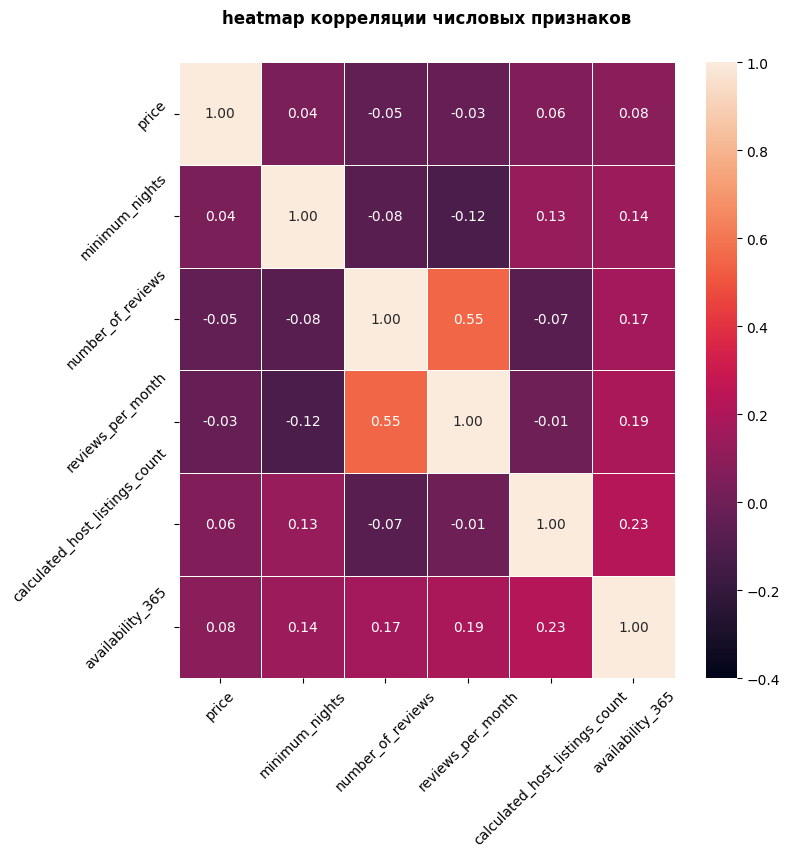

In [35]:
plt.figure(figsize=(8, 8))

sns.heatmap(data=corr_matrix, annot=True,  fmt=".2f", linewidth=.5, vmax=1, vmin=-0.4)

plt.title("heatmap корреляции числовых признаков", fontweight="bold", y=1.05)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

#### Промежуточный вывод:

* number_of_reviews и reviews_per_month - наибольшеая положительная корреляция. Зависимость признаков может объясняться тем, что чем больше отзывов жилище получаеь за месяц, тем больше растет общее количество отзывов
* price и остальные признаки - очень слабая корреляция, связи между ценой и другими числовыми признаками нет. Скорее всего ценовая политика формируется в зависимости от категориальных признаков - район и тип жилья, которые задают тренд ценообразованию

### pair plots

#### Подготовка данных

In [36]:
df_plots_filtered  = df_preinterim[ # ограничила значения нескольких признаков, чтобы не загромождать графики
    (df_preinterim["price"] < 500) &
    (df_preinterim["minimum_nights"] < 10) &
    (df_preinterim["number_of_reviews"] < 500)
]

df_plots_filtered

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
5,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
...,...,...,...,...,...,...,...,...,...,...,...
48889,Queens,Jamaica,40.69137,-73.80844,Private room,65,1,0,NaN,2,163
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [37]:
df_plots_sample = df_plots_filtered.sample(n=3000, random_state=123) # тк изначально график долго грузился, засемплировала 3к рандомных записей и построила график на основе обрезанного датафрейма
df_plots_sample

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
4527,Manhattan,Gramercy,40.73666,-73.97960,Private room,199,1,0,NaN,1,365
42438,Queens,South Ozone Park,40.67425,-73.82231,Entire home/apt,115,1,23,5.95,1,66
42485,Manhattan,Washington Heights,40.83713,-73.94827,Private room,65,3,0,NaN,1,87
8045,Manhattan,Upper West Side,40.79422,-73.97565,Private room,90,7,0,NaN,1,0
4684,Brooklyn,East New York,40.67517,-73.89814,Private room,135,1,173,4.69,3,162
...,...,...,...,...,...,...,...,...,...,...,...
20098,Brooklyn,Crown Heights,40.66675,-73.92958,Entire home/apt,73,2,4,0.16,1,0
11097,Brooklyn,Williamsburg,40.71681,-73.94080,Private room,70,5,22,0.48,2,359
8282,Brooklyn,Gowanus,40.67883,-73.98407,Private room,129,1,116,2.38,8,236
1915,Brooklyn,Prospect-Lefferts Gardens,40.66251,-73.95374,Entire home/apt,140,2,11,0.18,1,35


In [38]:
df_plots = df_plots_sample[["price", "minimum_nights", "number_of_reviews", "room_type", "neighbourhood_group"]] # семпл для графиков
df_plots

,price,minimum_nights,number_of_reviews,room_type,neighbourhood_group
4527,199,1,0,Private room,Manhattan
42438,115,1,23,Entire home/apt,Queens
42485,65,3,0,Private room,Manhattan
8045,90,7,0,Private room,Manhattan
4684,135,1,173,Private room,Brooklyn
...,...,...,...,...,...
20098,73,2,4,Entire home/apt,Brooklyn
11097,70,5,22,Private room,Brooklyn
8282,129,1,116,Private room,Brooklyn
1915,140,2,11,Entire home/apt,Brooklyn


#### Матрица парных графиков

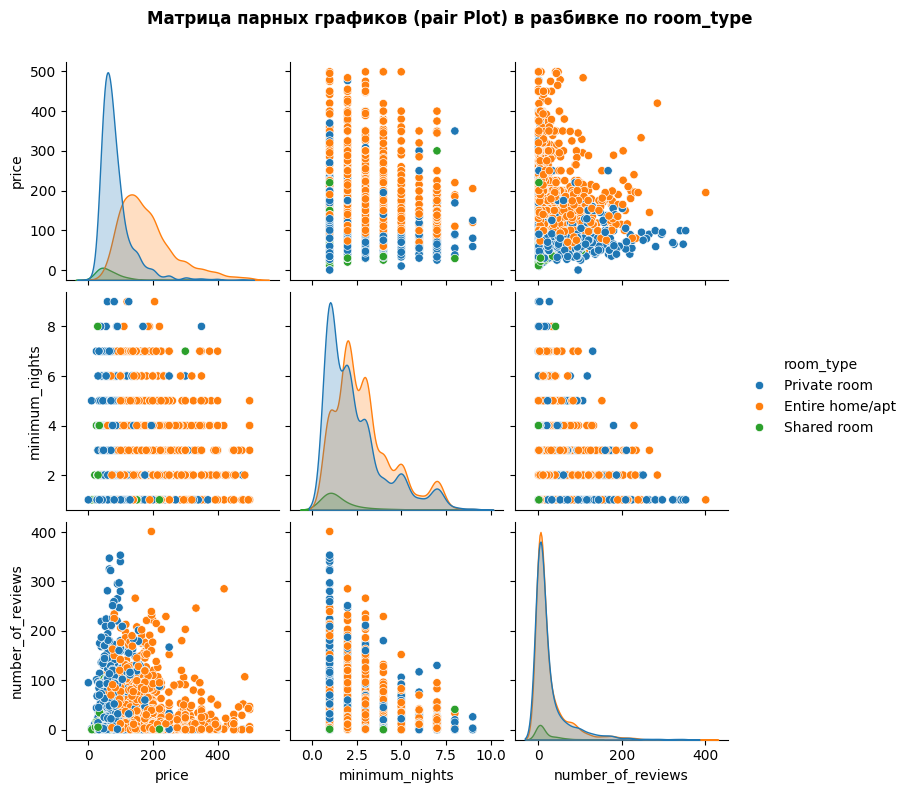

In [39]:
grid = sns.pairplot(data=df_plots, hue="room_type")

grid.figure.suptitle("Матрица парных графиков (pair Plot) в разбивке по room_type", fontweight="bold" , y=1.05)
plt.show()

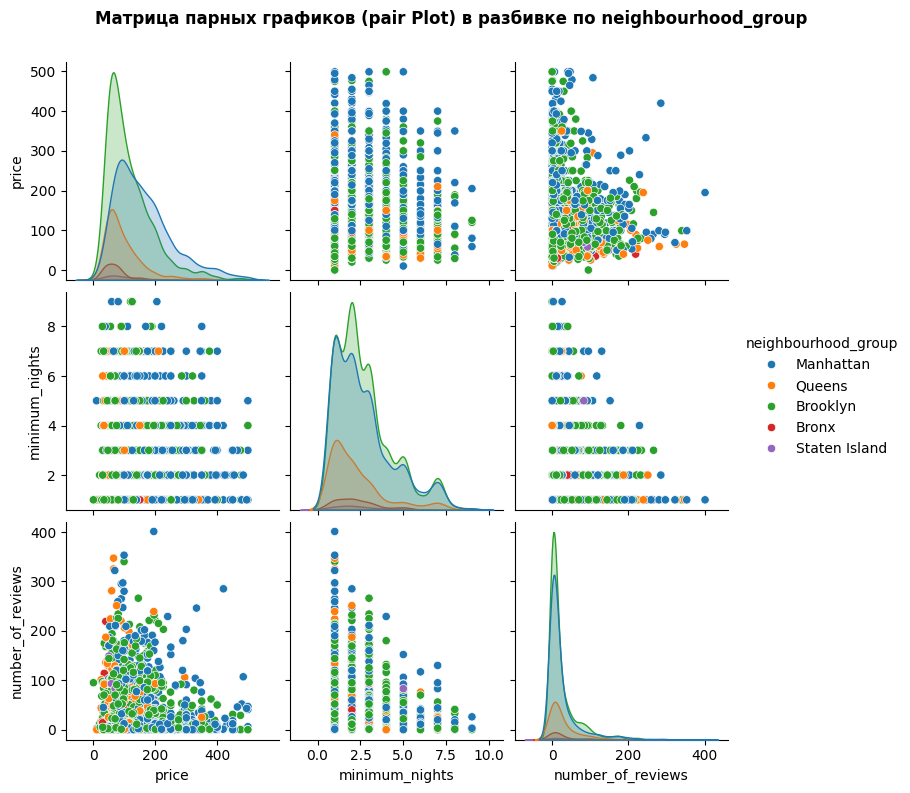

In [40]:
grid = sns.pairplot(data=df_plots, hue='neighbourhood_group')

grid.figure.suptitle('Матрица парных графиков (pair Plot) в разбивке по neighbourhood_group', fontweight='bold' , y=1.05)
plt.show()

#### Промежуточный вывод:

**Матрица парных графиков (pair Plot) в разбивке по room_type**

KDE<br>
Для всех числовых параметров характерны узкие высокие пики. Это говорит о высокой концентрации данных в конкретных числовых диапазонах<br>
Наблюдается незначительное смещение гривых на графике price и на графике minimum_nights. Для number_of_reviews смещение отсутсвует, в целом границы графиков повторяют друг друга. Это говорит об общих тенденциях, которым следуют числовые параметры

* price: ярко выражена разница цены между типом жилья "Private room" и типами жилья "Entire home/apt", "Shared rooms" 
* minimum_nights: ярко выражена разница длительности аренды для типов жилья "Private room", "Entire home/apt" и типа жилья "Shared rooms"
* number_of_reviews: аналогично minimum_nights

scatterplot<br>
Положительная корреляция между параметрами не наблюдается.

* number_of_reviews и price: большинство типов жилищ группируется в нижней левой части. Концентрация цены для данных типов жилья приходится на промежуток до 300$. При возрастании стоимости арнеды количество отзывов уменьшается. Также для типа жилья характерно наличие бОльшего количества отзывов, чем для остальных двух типов
* minimum_nights и price: для всех типов жилья характерно небольшое снижение цены за аренду при увеличении количества дней аренды жалья

**Матрица парных графиков (pair Plot) в разбивке по neighbourhood_group**

KDE<br>
Для всех числовых параметров характерны узкие высокие пики. Это говорит о высокой концентрации данных в конкретных числовых диапазонах<br>
Наблюдается незначительное смещение гривых на графике price и на графике minimum_nights. Для number_of_reviews смещение отсутсвует, в целом границы графиков повторяют друг друга. Это говорит об общих тенденциях, которым следуют числовые параметры

* price: ярко выражена разница цены аренды между районом "Brooklin" и остальными районами
* minimum_nights: ярко выражена разница длительности аренды в районах "Brooklin" и "Manhetten"
* number_of_reviews: аналогично minimum_nights

scatterplot<br>
Положительная корреляция между параметрами не наблюдается.

* number_of_reviews и price: наибольная доля всех районов группируется в нижней левой части. Концентрация цены жилищ в данных районах приходится на промежуток до 300$. При возрастании стоимости арнеды количество отзывов уменьшается. Также для типа жилья характерно наличие бОльшего количества отзывов, чем для остальных двух типов
* minimum_nights и price: во всех районах наблюдается схожая тенденция к ценообразованию аренды жилья в зависимости от длительности аренды

## Шаг 3. По результатам анализа произведите предобработку переменных

Меня смутило:

- минимальное значение $0$ для признака price
- максимальное значение $1250$ для призкана minimum_nights
- тип данных last_review строка, а не дата. Т.к. признак исключен на Шаге 1 - неактуально 

Соответсвенно буду производить предобработку по первым 2м пунктсам

**price**

In [41]:
filter_zero_price = df_preinterim[df_preinterim["price"] == 0]
len(filter_zero_price)

11

In [43]:
# тк признаков со значением 0 мало - удаляю
df_clean_price = df_preinterim[df_preinterim["price"] > 0]

print(f"Удалено {len(df_preinterim) - len(df_clean_price)} элементов")

Удалено 11 элементов


**minimum_nights**

In [44]:
filter_huge_minnights = df_clean_price[df_clean_price["minimum_nights"] > 365]
len(filter_huge_minnights)

14

In [45]:
# тк признаков со значением >365 мало - удаляю
df_interim = df_clean_price[df_clean_price["minimum_nights"] <= 365]

print(f"Удалено {len(df_clean_price) - len(df_interim)} элементов")

Удалено 14 элементов


In [46]:
len(df_interim)

48870

In [47]:
df_interim_path = Path("data/interim/AB_NYC_2019_interim.csv")

df_interim.to_csv(df_interim_path, sep=",", index=False)
print("Файл созранен по пути:", df_interim_path)

Файл созранен по пути: data\interim\AB_NYC_2019_interim.csv


# Часть 2. Preprocessing & Feature Engineering

Ваша цель — получить как можно более высокие метрики качества (можно взять несколько, R2, MAE, RMSE), сконцентрировавшись на преобразовании признаков.

Опробуйте различные техники:
   - работа с категориальными переменными (можно начать с dummy);
   - замена аномалий;
   - различные варианты шкалирования непрерывных переменных (StandardScaler, RobustScaler и т. д.);
   - обратите внимание на распределение целевой переменной, возможно, с ней тоже можно поработать;

   Попробуйте на основании имеющихся переменных создать новые, которые могли бы улучшить качество модели. Например, можно найти координаты Манхэттена (самого дорогого района) и при помощи широты и долготы, а также евклидова расстояния создать новую переменную — расстояние от квартиры до этого района. Возможно, такой признак будет работать лучше, чем просто широта и долгота. 

In [49]:
df_interim_path = Path("data/interim/AB_NYC_2019_interim.csv")

df_interim = pd.read_csv(df_interim_path, sep=',')

df_interim.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365


### Шаг 1. Работа с категориальными переменными

Кодирование признаков neighbourhood_group, room_type

In [52]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

cols_to_ohe = ["neighbourhood_group", "room_type"]

ohe_features_array = ohe.fit_transform(df_interim[cols_to_ohe])

df_encoded = pd.DataFrame(
    ohe_features_array, 
    columns=ohe.get_feature_names_out(cols_to_ohe)
)

df_encoded.head(3)

,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0


In [53]:
df_encoded_path = Path("data/processed/AB_NYC_2019_encoded.csv")

df_encoded.to_csv(df_encoded_path, sep=',', index=False)

### Шаг 2. Замена аномалий

В качестве аномалии я отметила очень высокую цену, верятно за жилье премиум-класса в элитной части района.<br>
Для обработки таких экстримальных значений буду производить каппинг, чтобы снова не урезать датасет

In [55]:
df_interim["price"].describe()

count    48870.000000
mean       152.759402
std        240.199363
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [56]:
extrim_price = df_interim["price"].quantile(0.99)
print(f"99% жилищь стоят дешевле {extrim_price}$")

99% жилищь стоят дешевле 799.0$


In [57]:
df_interim["price_capped"] = np.where(
    df_interim["price"] > extrim_price, # если цена больше extrim_price: 
    extrim_price, # если правда - замена такой цены на extrim_price
    df_interim["price"] # иначе - оставляю текущую price
)

df_interim.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,149.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,225.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,150.0


In [58]:
df_interim["price_capped"].describe()

count    48870.000000
mean       143.990464
std        121.936914
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max        799.000000
Name: price_capped, dtype: float64

### Шаг 3. Шкалирование непрерывных переменных

In [59]:
num_cols = df_interim.select_dtypes(include="number").columns.to_list()

In [60]:
num_features = [
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'availability_365',
]

df_processed = df_interim.copy()

df_processed[num_features] = RobustScaler().fit_transform(df_processed[num_features])

In [61]:
df_processed.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,-0.5,0.173913,-0.278689,6,1.409692,149.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,-0.5,1.739130,-0.185792,2,1.365639,225.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,0.0,-0.217391,NaN,1,1.409692,150.0


### Шаг 4. Работа с целевой переменной

На шаге 2 было выявлено, что распределение целевой переменной имеет ярковыраженную скошенность вправо. Я отдала предпочтение логарифмированию, тк логарифм позволит подтянуть выбросы ближе к основной части значений и приблизить распределение к нормальному

In [62]:
df_processed["log_price_capped"] = np.log(df_processed["price_capped"])
df_processed.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped,log_price_capped
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,-0.5,0.173913,-0.278689,6,1.409692,149.0,5.003946
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,-0.5,1.739130,-0.185792,2,1.365639,225.0,5.416100
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,0.0,-0.217391,NaN,1,1.409692,150.0,5.010635


In [63]:
df_processed_path = Path("data/processed/AB_NYC_2019_processed.csv")

df_processed.to_csv(df_processed_path, sep=",", index=False)
print("Файл созранен по пути:", df_processed_path)

Файл созранен по пути: data\processed\AB_NYC_2019_processed.csv


### Шаг 5. Создание новых переменных на основе координат

   Попробуйте на основании имеющихся переменных создать новые, которые могли бы улучшить качество модели. Например, можно найти координаты Манхэттена (самого дорогого района) и при помощи широты и долготы, а также евклидова расстояния создать новую переменную — расстояние от квартиры до этого района. Возможно, такой признак будет работать лучше, чем просто широта и долгота. 

Координаты центра Манхеттена в десячиных градусах : 40.7909, -73.9664

=> Формула Евклидова расстояния между координатами апартов ($lt_a$, $lg_a$) и центром Манхеттена ($lt_c$, $lg_c$):
    
$d(p,q)=\sqrt{(lt_a-lt_c)^{2}+(lg_a-lg_c)^{2}}$

In [64]:
lt_c = 40.7909
lg_c = -73.9664

df_processed["euclid_distance_manhattan"] = np.sqrt(
    (df_processed["latitude"] - lt_c)**2 +
    (df_processed["longitude"] - lg_c)**2
)
df_processed.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped,log_price_capped,euclid_distance_manhattan
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,-0.5,0.173913,-0.278689,6,1.409692,149.0,5.003946,0.143534
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,-0.5,1.739130,-0.185792,2,1.365639,225.0,5.416100,0.041128
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,0.0,-0.217391,NaN,1,1.409692,150.0,5.010635,0.030473


Есть более подходящая формула гаверсинусов, т.к. она учитывает кривизну Змели. И я буквально недавно использовала ее в своей рабочей задаче :) 

Предлагаю такой признак тоже рассчитать и сравнить разницу с euclid_distance_manhattan. Формула состоит из двух шагов:
1. Нахождение углового расстояния
$a=\sin ^{2}\left(\frac{\Delta lt}{2}\right)+\cos (lt_{a})\cdot \cos (lt_{c})\cdot \sin ^{2}\left(\frac{\Delta lg}{2}\right)$
2. Расчет финального расстояния $d=2\cdot R\cdot \arcsin (\sqrt{a})$



In [65]:
R = 6371.0 # - радиус земли

lt_a_rad = np.radians(df_processed["latitude"])
lg_a_rad = np.radians(df_processed["longitude"])
lt_c_rad = np.radians(lt_c)
lg_c_rad = np.radians(lg_c)

df_processed["haversine_distance_manhattan"] = 2 * R * np.arcsin(
    np.sqrt(
        np.sin((lt_c_rad - lt_a_rad) / 2)**2 +
        np.cos(lt_a_rad) *
        np.cos(lt_c_rad) *
        np.sin((lg_c_rad - lg_a_rad) / 2)**2
    )
)

df_processed.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped,log_price_capped,euclid_distance_manhattan,haversine_distance_manhattan
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,-0.5,0.173913,-0.278689,6,1.409692,149.0,5.003946,0.143534,15.954400
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,-0.5,1.739130,-0.185792,2,1.365639,225.0,5.416100,0.041128,4.395842
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,0.0,-0.217391,NaN,1,1.409692,150.0,5.010635,0.030473,2.883152


И теперь сравниваем 2 признака. 

Предварительно Евклидово расстояние нужно перевести из градусов в км

In [66]:
df_processed["euclid_distance_manhattan_km"] = np.sqrt(
    ((df_processed["latitude"] - lt_c) * 111.0) ** 2 # 1 градус широты ~ 111 км в районе 40° с.ш.
    + ((df_processed["longitude"] - lg_c) * 84.2) ** 2 # 1 градус долготы ~ 84.2 км в районе 40° с.ш.
)

df_processed["abs_error_km"] = np.abs(
    df_processed["haversine_distance_manhattan"] - df_processed["euclid_distance_manhattan_km"]
)

df_processed["pct_error"] = (
    df_processed["abs_error_km"] / df_processed["haversine_distance_manhattan"]
) * 100

print("Статистика расхождений:")
print(df_processed[["abs_error_km", "pct_error"]].describe())

Статистика расхождений:
       abs_error_km     pct_error
count  4.887000e+04  48870.000000
mean   1.320644e-02      0.142616
std    8.787541e-03      0.043980
min    1.219008e-08      0.000003
25%    5.597959e-03      0.131034
50%    1.292754e-02      0.163157
75%    1.944662e-02      0.172412
max    7.321550e-02      0.183964


Вывод: для данной задачи - евклид вполне применимый и более простой аналог расчетов. Так как средняя разница 0.142616% и в саксимальная ошибка 0.183964% - несущественная разница

Итог - оставляю в датасете euclid_distance_manhattan, шкалирую latitude и longitude

In [67]:
df_processed.columns.tolist()

['neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'price_capped',
 'log_price_capped',
 'euclid_distance_manhattan',
 'haversine_distance_manhattan',
 'euclid_distance_manhattan_km',
 'abs_error_km',
 'pct_error']

In [68]:
dist_features = [
 'latitude',
 'longitude'
]

cols_to_drop = [
 'haversine_distance_manhattan',
 'euclid_distance_manhattan_km',
 'abs_error_km',
 'pct_error'
] 

df_processed[dist_features] = RobustScaler().fit_transform(df_processed[dist_features])

df_processed_final = df_processed.drop(columns=cols_to_drop)
df_processed_final.head(3)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_capped,log_price_capped,euclid_distance_manhattan
0,Brooklyn,Kensington,-1.034983,-0.356410,Private room,149,-0.5,0.173913,-0.278689,6,1.409692,149.0,5.003946,0.143534
1,Manhattan,Midtown,0.418156,-0.600000,Entire home/apt,225,-0.5,1.739130,-0.185792,2,1.365639,225.0,5.416100,0.041128
2,Manhattan,Harlem,1.176696,0.294658,Private room,150,0.0,-0.217391,NaN,1,1.409692,150.0,5.010635,0.030473


In [69]:
df_processed_final_path = Path("data/processed/AB_NYC_2019_processed_final.csv")

df_processed_final.to_csv(df_processed_final_path, sep=",", index=False)
print("Файл созранен по пути:", df_processed_final_path)

Файл созранен по пути: data\processed\AB_NYC_2019_processed_final.csv


# Часть 3. Моделирование

1. Отложите 30% данных для тестирования.
2. Постройте модели простой линейной регрессии, RidgeCV, LassoCV и ElasticNetCV.
3. Измерьте качество каждой и визуализируйте важность признаков.
4. Сделайте интересные выводы :)

In [2]:
df_processed_final_path = Path("data/processed/AB_NYC_2019_processed_final.csv")

df_processed_final = pd.read_csv(df_processed_final_path, sep=",", encoding="utf-8")

In [9]:
df_encoded_path = Path("data/processed/AB_NYC_2019_encoded.csv")

df_encoded = pd.read_csv(df_encoded_path, sep=",", encoding="utf-8")

### Шаг 1. Отложите 30% данных для тестирования.

In [10]:
num_features_to_use = [
 "latitude",
 "longitude",
 "minimum_nights",
 "number_of_reviews",
 "availability_365",
 "euclid_distance_manhattan"
]

X = pd.concat( #тут по колонкам объединяю предобработанный датасет и датасет с закодированными на шаге "Шаг 1. Работа с категориальными переменными" neighbourhood_group и room_type
    [
        df_processed_final[num_features_to_use].reset_index(drop=True),
        df_encoded.reset_index(drop=True)
    ],
    axis=1
)

y = df_processed_final["log_price_capped"].reset_index(drop=True)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y, test_size=0.3, random_state=123)

print(f"Размер обучающей выборки: {X_train.shape[0]} жилищ")
print(f"Размер тестовой выборки: {X_test.shape[0]} жилищ")

Размер обучающей выборки: 34209 жилищ
Размер тестовой выборки: 14661 жилищ


In [11]:
df_processed_final[num_features_to_use].isna().sum()

latitude                     0
longitude                    0
minimum_nights               0
number_of_reviews            0
availability_365             0
euclid_distance_manhattan    0
dtype: int64

### Шаг 2. Постройте модели простой линейной регрессии, RidgeCV, LassoCV и ElasticNetCV.

### Шаг 3. Измерьте качество каждой и визуализируйте важность признаков.

In [70]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge CV": RidgeCV(alphas=np.logspace(-3, 3, 10)),
    "Lasso CV": LassoCV(alphas=np.logspace(-3, 3, 10), random_state=123),
    "ElasticNet CV": ElasticNetCV(alphas=np.logspace(-3, 3, 10), l1_ratio=[0.1, 0.5, 0.7, 0.9], random_state=123)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)

    y_pred = np.exp(y_pred_log) # т.к. я применяла логарифм к цене - делаю обратную операцию, чтобы вернуть $
    y_test = np.exp(y_test_log)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test_log, y_pred_log)

    results.append(
        {
        "Модель":name,
        "MAE ($)": mae,
        "RMSE ($)": rmse,
        "R2": r2
        }
    )

df_results = pd.DataFrame(results)
df_results

,Модель,MAE ($),RMSE ($),R2
0,Linear Regression,53.803968,101.938922,0.507024
1,Ridge CV,53.803603,101.939052,0.507029
2,Lasso CV,53.968977,102.275035,0.502489
3,ElasticNet CV,53.869087,102.128260,0.504820


In [71]:
importance = pd.DataFrame(
    {
        "Признак": X.columns, 
        "Вес Linear": models["Linear Regression"].coef_,
        "Вес Ridge": models["Ridge CV"].coef_,
        "Вес Lasso": models["Lasso CV"].coef_,
        "Вес ElasticNet": models["ElasticNet CV"].coef_
    }
)
importance

,Признак,Вес Linear,Вес Ridge,Вес Lasso,Вес ElasticNet
0,latitude,-0.177968,-0.176863,-0.032040,-0.073693
1,longitude,-0.084924,-0.085368,-0.131599,-0.121176
2,minimum_nights,-0.012017,-0.012014,-0.011358,-0.011638
3,number_of_reviews,-0.017103,-0.017104,-0.016829,-0.017092
4,availability_365,0.173480,0.173460,0.166449,0.169895
5,euclid_distance_manhattan,-2.431524,-2.412066,-0.000000,-0.664351
6,neighbourhood_group_Brooklyn,-0.243492,-0.241645,-0.000000,-0.056346
7,neighbourhood_group_Manhattan,0.085626,0.087267,0.295187,0.251223
8,neighbourhood_group_Queens,-0.121822,-0.120016,0.086029,0.050070
9,neighbourhood_group_Staten Island,-0.669330,-0.669898,-0.592721,-0.621172


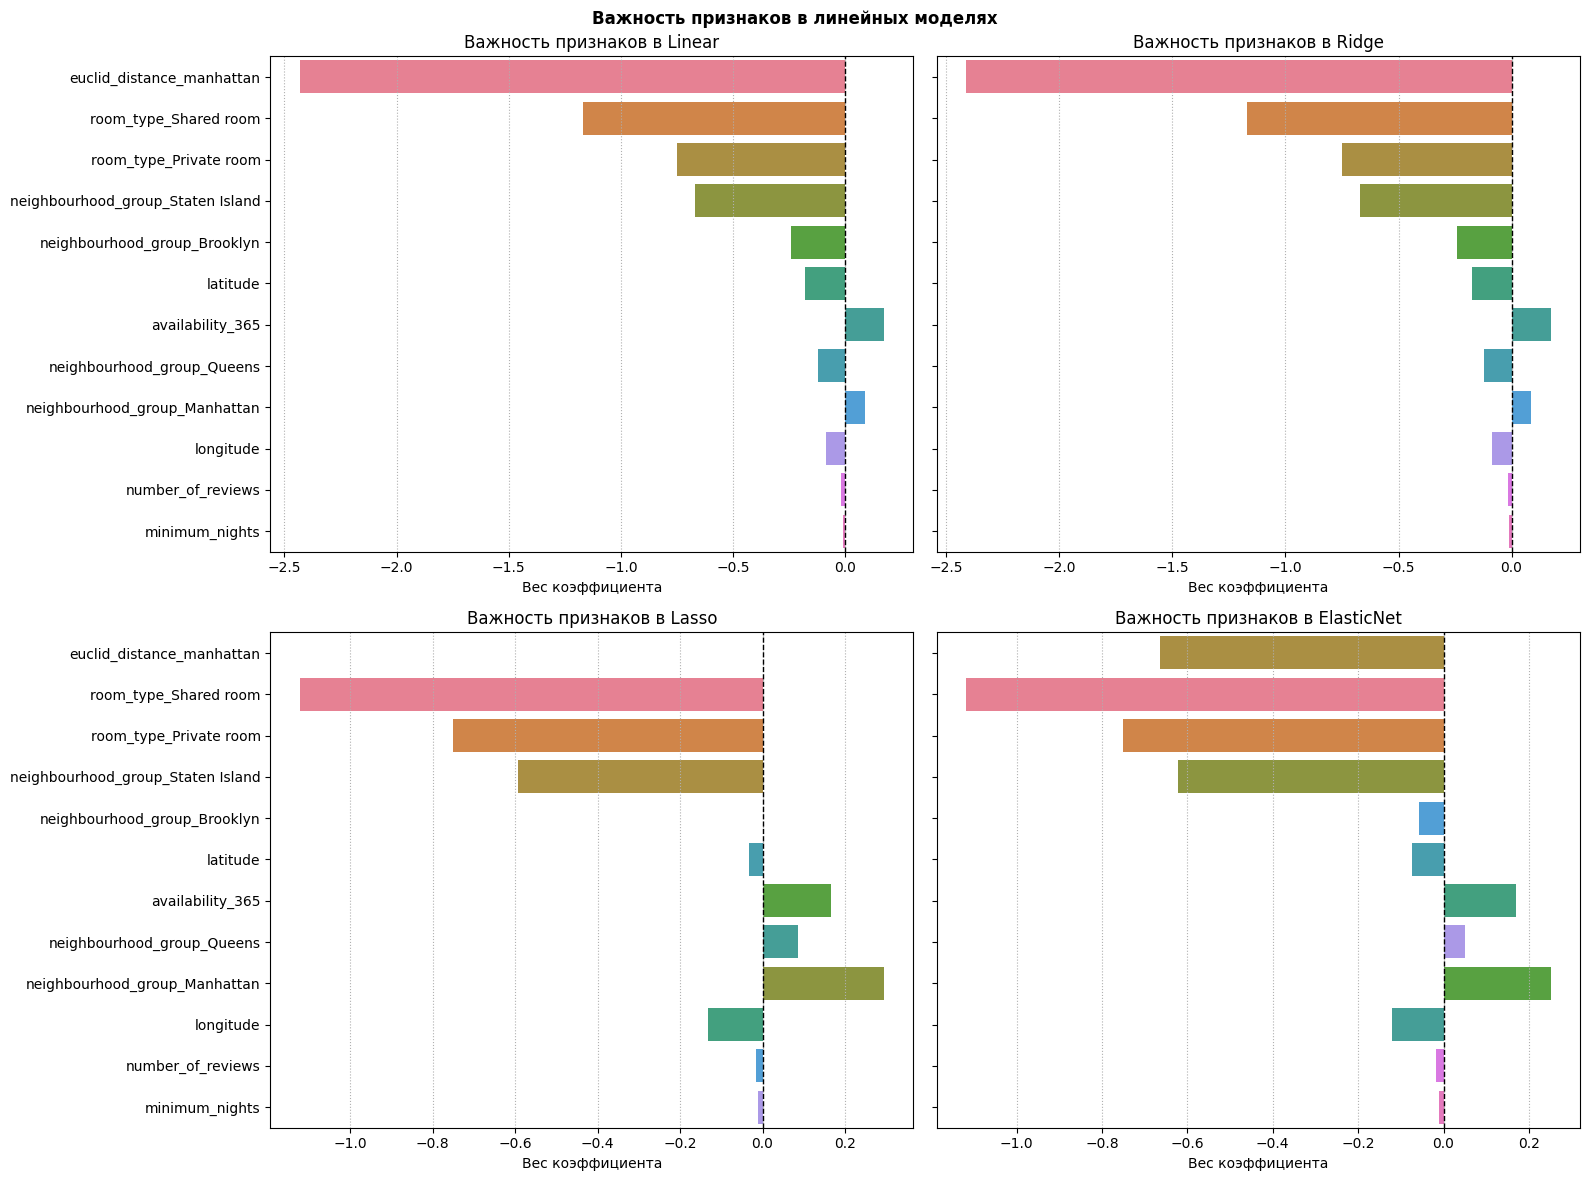

In [72]:
models_list = ["Вес Linear", "Вес Ridge", "Вес Lasso", "Вес ElasticNet"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

for i, model_col in enumerate(models_list):
    df_plot = importance[["Признак", model_col]].copy()
    df_plot["Абсолютный_вес"] = df_plot[model_col].abs()
    df_plot = df_plot.sort_values(by="Абсолютный_вес", ascending=False)

    sns.barplot(
        x=model_col,
        y="Признак",
        data=df_plot,
        hue="Признак",
        ax=axes[i],
    )

    axes[i].set_title(f"Важность признаков в {model_col.replace('Вес ', '')}")
    axes[i].set_xlabel("Вес коэффициента")
    axes[i].set_ylabel("")
    axes[i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[i].grid(axis="x", linestyle=':', zorder=0)

# Общий заголовок для всей фигуры
plt.suptitle("Важность признаков в линейных моделях", weight="bold")
plt.tight_layout()
plt.show()


### Шаг 4. Сделайте интересные выводы :)

**MAE ($)**

Метрика показывает размер ошибки в среднем, т.е. все модели ошибаются примерно на  53.8-53.9 доллара. <br>
Средняя ошибка у всех моделей очень близка. С т.з. обучения моделей это означает, что среди всего класса моделей базовая линейная регрессия не склонная к переобучению: признаки не создают сильную мультиколлинеарность и регуляризация правтически не изменила качество предсказания модели.<br>

**RMSE ($)**

Метрика показывает корень среднеквадратичной ошибки. Из-за возведения в квадрат метрика крайне чувствительна к выбросам, которые по резульатам EDA присутствуют в датасете. В связи с такими аномалиями модель сильно ошибается, что повлияло на итоговый RMSE. Разница с MAE почти в 2 раза также говорит о том, что в данных присусвтуют аномально высокие значения, на которых модели совершают ошибки, сильно штрафующие RMSE.<br>

**R2**

Метрика показывает долю дисперсии целевой переменной, которую смогла модель объяснить. Для каждой модели R2=0.5 - это говорит о том, что модели смогли объяснить 50% изменчивости цен на аренду.

**Визуализация весов**

Визуализация показала, что разные модели исходят из разных стратегий при работе с географическими признаками: 
* Linear, Ridge и частично ElasticNet опираются на синтетический признак euclid_distance_manhattan - вероятно потому что им с ним проще работать
* А Lasso полностью обнулила коэффициент этого признака, и как будто больше сосредоточилась на бинарных представлениях признаков neighbourhood_group, спроектированных на шаге "Шаг 1. Работа с категориальными переменными". 

При этом значения итоговых метрик моделей очень близки. Отсюда можно сделать вывод, что модели использовали разные, но математически равнозначные комбинации признаков для описания географии цен.

**Общий вывод**

С т.з. бизнеса я бы оценила модели с таким резульатом обучения как неэффективные. Медианное значение цены по датасету в целом - 106$, и 75% жилья для аренды стоит до 175$. Средняя ошибка в 53$ при предсказании стоимости аренды квартиры в контексте бизнеса создает очень стильную неопределенность - модель в среднем может предсказать в половину больше или меньше реальной стоимости аренды. С точки зрения прибыльности в упрощенной перспективе это станет либо причиной снижения спроса из-за оверпрайса, либо к приведет к упущенной выгоды из-за слишком низкой цены.<br>
В совокупности с тем, что модели объясняют всего 50% дисперсий текущее решение нельзя назвать эффективным.

Среди всех моделей наиболее оптимально показала себя Ridge CV, т.к. у нее наименьший MAE и наибольший R2. Я бы зафиксровала эту модель в качестве baseline и рассмотрела бы более продвинутые алгоритмы обучения, чтобы попытаться добиться более качественного результата обучения.